In [4]:
# the torch implementation of ShiftMorph

import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F


# spatial transformer methods
def to_world_flow(flow: torch.Tensor) -> torch.Tensor:
    device = flow.device
    size_tensor = torch.tensor(flow.shape[2:], device=device).view(1, 3, 1, 1, 1)
    flow = flow.flip(1)  # to world dimension order
    flow *= size_tensor * 0.5
    return flow


def to_torch_grid(grid: torch.Tensor) -> torch.Tensor:
    size_tensor = torch.tensor(grid.shape[1:4], device=grid.device).view(1, 1, 1, 1, 3)
    grid = grid / (size_tensor - 1) * 2 - 1
    grid = grid.flip(-1)  # To pytorch dimension order
    return grid


class Morpher(torch.nn.Module):
    grid: torch.Tensor
    shape: torch.Size

    def __init__(self) -> None:
        super().__init__()
        self.shape = None

    def identity_grid_cache(self, shape, device):
        if self.shape != shape:
            grid = torch.meshgrid([torch.arange(0, sz, device=device) for sz in shape], indexing="ij")
            grid = torch.stack(grid, dim=-1)
            self.shape = shape
            self.register_buffer("grid", grid, persistent=False)

        if self.grid.device != device:
            self.grid = self.grid.to(device)
        return self.grid

    def warp(self, src: torch.Tensor, flow: torch.Tensor, mode="bilinear", align_corners=True):
        grid = self.identity_grid_cache(flow.shape[2:], flow.device)
        grid = grid + flow.moveaxis(1, -1)
        grid = to_torch_grid(grid)
        warped = F.grid_sample(src, grid, mode=mode, align_corners=align_corners)
        return warped

    def compose(self, flow1, flow2, mode="bilinear", align_corners=True):
        flow = flow2 + self.warp(flow1, flow2, mode=mode, align_corners=align_corners)
        return flow


# ShiftMorph implementation

BIAS = True
Normlizer = lambda ch: nn.InstanceNorm3d(ch)
Activation = lambda: nn.PReLU()
Pool = lambda: nn.AvgPool3d(2, 2)


class ConvBlock(nn.Sequential):

    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super().__init__()
        self.conv = nn.Conv3d(in_channels, out_channels, kernel_size, stride, padding, bias=BIAS)
        self.norm = Normlizer(out_channels)
        self.activation = Activation()


class ShiftDecoder(nn.Module):

    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()
        self.down = nn.Sequential(
            nn.Conv3d(skip_channels, skip_channels, 4, 2, 1, bias=BIAS),
            Normlizer(skip_channels),
        )
        self.conv = nn.Sequential(
            nn.ConvTranspose3d(in_channels + skip_channels, out_channels, 4, 2, 1, bias=BIAS),
            Normlizer(out_channels),
            Activation(),
        )

    def forward(self, x, skip):
        x = torch.cat([x, self.down(skip)], dim=1)
        x = self.conv(x)
        return x


class DecoderBlock(nn.Module):

    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.ConvTranspose3d(in_channels + skip_channels, out_channels, 4, 2, 1, bias=BIAS),
            Normlizer(out_channels),
            Activation(),
        )

    def forward(self, x, skip):
        x = torch.cat([x, skip], dim=1)
        x = self.conv(x)
        return x


class ShiftEmbedding(torch.nn.Module):

    def __init__(self, in_channels=2, embed_dim=16, patch_size=4, stride=2, padding=1, flip_second=True):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Conv3d(in_channels, embed_dim, patch_size, stride, padding, bias=BIAS),
            Normlizer(embed_dim),
        )
        self.SHIFTS = [(0, 0, 0), (1, 0, 0), (0, 1, 0), (0, 0, 1), (0, 1, 1), (1, 0, 1), (1, 1, 0), (1, 1, 1)]
        self.flip_second = flip_second

    def forward(self, x: torch.Tensor, n_shifts=8):
        B, C, H, W, T = x.shape
        x = F.pad(x, pad=(0, 1, 0, 1, 0, 1))
        shifts = []
        shift_pos = self.SHIFTS[:n_shifts]
        for idx in range(n_shifts):
            i, j, k = shift_pos[idx]
            if not self.training or not self.flip_second or idx < 4:
                shifts.append(x[:, :, i : i + H, j : j + W, k : k + T])
            else:
                # flip the channel to reverse the registration direction
                shifts.append(x[:, :, i : i + H, j : j + W, k : k + T].flip(dims=[1]))

        shifts = torch.cat(shifts, dim=1).view(B * n_shifts, C, H, W, T)
        embed = self.proj(shifts)
        return embed


class ShiftMorph(nn.Module):

    def __init__(self, embed_dim, flip_second=True) -> None:
        super().__init__()
        CONV = ConvBlock
        ch = embed_dim
        self.flip_second = flip_second
        self.embedding = ShiftEmbedding(2, ch, 4, 2, 1, flip_second)
        self.conv1 = CONV(ch, ch * 2)
        self.down1 = Pool()
        self.conv2 = CONV(ch * 2, ch * 4)
        self.down2 = Pool()
        self.conv3 = CONV(ch * 4, ch * 8)
        self.down3 = Pool()
        self.bottle = CONV(ch * 8, ch * 16)
        self.decoder3 = ShiftDecoder(ch * 16, ch * 8, ch * 8)
        self.decoder2 = ShiftDecoder(ch * 8, ch * 4, ch * 4)
        self.decoder1 = ShiftDecoder(ch * 4, ch * 2, ch * 2)

        self.reg_head = nn.Sequential(
            ConvBlock(ch * 2, ch),
            ConvBlock(ch, ch),
            nn.Conv3d(ch, 3, 3, 1, 1),
            nn.Tanh(),
            nn.Upsample(scale_factor=2.0, mode="trilinear", align_corners=False),
        )
        self.stn = Morpher()

    def forward(self, fix: torch.Tensor, mov: torch.Tensor) -> torch.Tensor:
        if self.training:
            return self.full_forward(fix, mov)
        else:
            return self.half_forward(fix, mov)

    def full_forward(self, fix: torch.Tensor, mov: torch.Tensor) -> torch.Tensor:
        x_in = torch.cat([fix, mov], dim=1)
        B, C, H, W, D = x_in.shape
        embedded = self.embedding(x_in)

        f1 = self.conv1(embedded)
        f2 = self.conv2(self.down1(f1))
        f3 = self.conv3(self.down2(f2))
        out = self.bottle(self.down3(f3))

        f1 = f1.view(-1, 4, *f1.shape[1:]).mean(dim=1, keepdim=False)
        f2 = f2.view(-1, 4, *f2.shape[1:]).mean(dim=1, keepdim=False)
        f3 = f3.view(-1, 4, *f3.shape[1:]).mean(dim=1, keepdim=False)
        out = out.view(-1, 4, *out.shape[1:]).mean(dim=1, keepdim=False)

        out = self.decoder3(out, f3)
        out = self.decoder2(out, f2)
        out = self.decoder1(out, f1)

        flow = self.reg_head(out) * 0.3
        flow = to_world_flow(flow)
        flow = flow.view(-1, 6, *flow.shape[2:])

        flow, inv_flow = torch.split(flow, split_size_or_sections=3, dim=1)

        if not self.flip_second:
            inv_flow = inv_flow.negative()

        self.cache_for_consistency_loss = self.stn.compose(flow, inv_flow)
        return flow

    def half_forward(self, fix: torch.Tensor, mov: torch.Tensor) -> torch.Tensor:

        x_in = torch.cat([fix, mov], dim=1)
        B, C, H, W, D = x_in.shape
        embedded = self.embedding(x_in, 4)

        f1 = self.conv1(embedded)
        f2 = self.conv2(self.down1(f1))
        f3 = self.conv3(self.down2(f2))
        out = self.bottle(self.down3(f3))

        f1 = f1.view(-1, 4, *f1.shape[1:]).mean(dim=1, keepdim=False)
        f2 = f2.view(-1, 4, *f2.shape[1:]).mean(dim=1, keepdim=False)
        f3 = f3.view(-1, 4, *f3.shape[1:]).mean(dim=1, keepdim=False)
        out = out.view(-1, 4, *out.shape[1:]).mean(dim=1, keepdim=False)

        out = self.decoder3(out, f3)
        out = self.decoder2(out, f2)
        out = self.decoder1(out, f1)
        flow = self.reg_head(out) * 0.3
        flow = to_world_flow(flow)
        return flow

In [5]:
# runtime performance

import time

model = ShiftMorph(16, True)
model.eval()

fixed_img_tensor = torch.randn(1, 1, 160, 192, 224)
moving_img_tensor = torch.randn(1, 1, 160, 192, 224)

count_param = 0
for params in model.parameters():
    count_param += params.numel()

print(f"Parameters of ShiftMorph: {count_param/1000/1000:.2f}M")
with torch.no_grad():
    if torch.cuda.is_available():
        device = "cuda:0"
        model = model.to(device)
        fixed_img_tensor = fixed_img_tensor.to(device)
        moving_img_tensor = moving_img_tensor.to(device)
        for i in range(5):
            flow = model.forward(fixed_img_tensor, moving_img_tensor)
        torch.cuda.synchronize()
        time_list = []

        for i in range(100):
            torch.cuda.synchronize()
            s = time.time()
            flow = model.forward(fixed_img_tensor, moving_img_tensor)
            torch.cuda.synchronize()
            time_list.append(time.time() - s)

        infer_time = np.mean(time_list) * 1000
        print(f"GPU time per pair of ShiftMorph: {infer_time:.2f}ms")

    device = "cpu"
    model = model.to(device)
    fixed_img_tensor = fixed_img_tensor.to(device)
    moving_img_tensor = moving_img_tensor.to(device)
    time_list = []
    for i in range(5):
        s = time.time()
        flow = model.forward(fixed_img_tensor, moving_img_tensor)
        time_list.append(time.time() - s)

    infer_time = np.mean(time_list) * 1000
    print(f"CPU time per pair of ShiftMorph: {infer_time:.2f}ms")

Parameters of ShiftMorph: 6.71M
GPU time per pair of ShiftMorph: 25.18ms
CPU time per pair of ShiftMorph: 797.76ms


Testing with noisy level 0


/tmp/ipykernel_230608/1066308570.py:56: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("logs/model_weight.pth", map_location=device))


Dice score = 0.8315


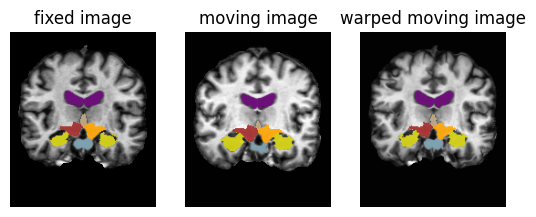

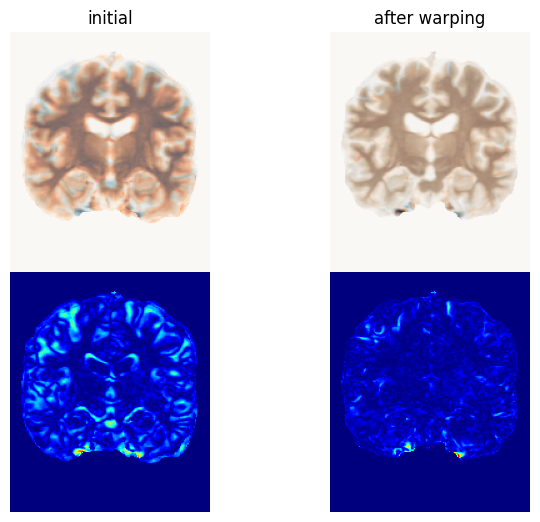

Testing with noisy level 30
Dice score = 0.8037


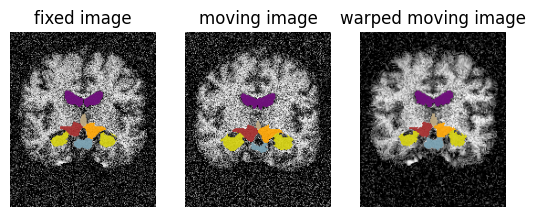

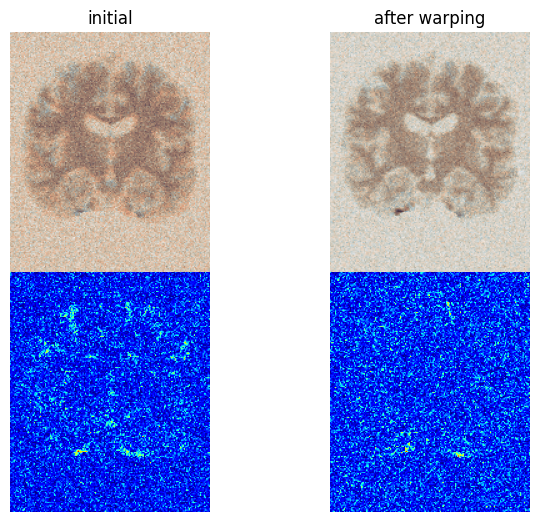

In [6]:
import pickle
from skimage.exposure import equalize_adapthist, adjust_gamma
import matplotlib.pyplot as plt
%matplotlib inline

def overlay_img(img1, img2, ax, cmaps=["Blues", "Oranges"], title=None, alpha=0.5):
    ax.imshow(img1.squeeze(), cmap=cmaps[0])
    ax.imshow(img2.squeeze(), cmap=cmaps[1], alpha=alpha)
    if title is not None:
        ax.title.set_text(title)
    ax.axis("off")


# display function
def display_slice(img, seg, label_list, slice_index, ax=None, title=""):
    color_map = np.array(
        # a color lookup table from freesurfer
        [
            # fmt: off
            [0, 0, 0, 0], [245, 245, 245, 0], [205, 62, 78, 0], [120, 18, 134, 0], [196, 58, 250, 0], [220, 248, 164, 0],
            [230, 148, 34, 0], [0, 118, 14, 0], [122, 186, 220, 0], [236, 13, 176, 0], [12, 48, 255, 0], [204, 182, 142, 0],
            [42, 204, 164, 0], [119, 159, 176, 0], [220, 216, 20, 0], [103, 255, 255, 0], [60, 60, 60, 0], [255, 165, 0, 0],
            [165, 42, 42, 0], [0, 200, 200, 0], [245, 245, 245, 0], [205, 62, 78, 0], [120, 18, 134, 0], [196, 58, 250, 0],
            [220, 248, 164, 0], [230, 148, 34, 0], [0, 118, 14, 0], [122, 186, 220, 0], [236, 13, 176, 0], [13, 48, 255, 0],
            [220, 216, 20, 0], [103, 255, 255, 0], [255, 165, 0, 0], [165, 42, 42, 0], [0, 200, 221, 0], [200, 70, 255, 0],
            # fmt: on
        ]
    )
    color_map = color_map[:, :3] / 255.0
    H, W, T = img.shape
    img = np.clip(img, a_min=0, a_max=1)
    img = img[..., slice_index].T
    img = equalize_adapthist(img, 50, nbins=256)
    img = np.repeat(img[..., None], repeats=3, axis=-1)
    seg = seg[..., slice_index].T
    for idx, label in enumerate(label_list):
        mask = seg == label
        color = color_map[label]
        img[mask] = img[mask] * 0.1 + color * 0.9
    img = np.array(img * 255, dtype='uint8')

    ax = ax or plt.gca()
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(title)


with open("logs/OASIS_brain_MRI.pkl", "rb") as file:
    img_dict = pickle.load(file)


device = "cuda:0" if torch.cuda.is_available() else "cpu"
selected_labels = [3, 11, 13, 14, 17, 22, 33, 30] # You may choose other labels according to `asegColorLUT.txt`
slice_index = 110
model = model.to(device)
model.load_state_dict(torch.load("logs/model_weight.pth", map_location=device))
model.eval()
np.random.seed(777)
# results may slightly change with different random state

for STD in [0, 30]: # the Gaussian noise level
    print(f"Testing with noisy level {STD}")

    fixed_img = img_dict['fixed_image'].astype("float32") / 255
    fixed_seg = img_dict['fixed_label']
    moving_img = img_dict['moving_image'].astype("float32") / 255
    moving_seg = img_dict['moving_label']

    fixed_img = fixed_img + np.random.randn(*fixed_img.shape) * STD / 255
    moving_img = moving_img + np.random.randn(*fixed_img.shape) * STD / 255

    fixed_img_tensor = torch.from_numpy(fixed_img)[None, None, ...].float().to(device)
    moving_img_tensor = torch.from_numpy(moving_img)[None, None, ...].float().to(device)
    moving_seg_tensor = torch.from_numpy(moving_seg)[None, None, ...].float().to(device)

    with torch.no_grad():
        flow = model.forward(fixed_img_tensor, moving_img_tensor)
    warped_img = model.stn.warp(moving_img_tensor, flow).cpu().numpy().squeeze()
    warped_seg = model.stn.warp(moving_seg_tensor, flow, mode='nearest').long().cpu().numpy().squeeze()

    dice = []
    for i in range(1, fixed_seg.max() + 1):
        A = np.ravel(fixed_seg == i)
        B = np.ravel(warped_seg == i)
        dice_each = 2 * np.sum(A * B) / (np.sum(A) + np.sum(B))
        dice.append(dice_each)
    dice_mean = np.mean(dice)
    print(f"Dice score = {dice_mean:.4f}")

    fig, axes = plt.subplots(1, 3)
    display_slice(fixed_img, fixed_seg, selected_labels, slice_index, axes[0], "fixed image")
    display_slice(moving_img, moving_seg, selected_labels, slice_index, axes[1], "moving image")
    display_slice(warped_img, warped_seg, selected_labels, slice_index, axes[2], "warped moving image")

    fig, axes = plt.subplots(2, 2)
    fig.subplots_adjust(left=0, right=1, bottom=0, top=1, wspace=0.0, hspace=0.0)
    fixed_slice = fixed_img[..., slice_index].T
    moving_slice = moving_img[..., slice_index].T
    warped_slice = warped_img[..., slice_index].T

    overlay_img(fixed_slice, moving_slice, ax=axes[0, 0], title='initial')
    overlay_img(fixed_slice, warped_slice, ax=axes[0, 1], title='after warping')
    axes[1, 0].imshow(np.abs(fixed_slice - moving_slice), cmap='jet')
    axes[1, 0].axis("off")
    axes[1, 1].imshow(np.abs(fixed_slice - warped_slice), cmap='jet')
    axes[1, 1].axis("off")
    plt.show()